<a href="https://colab.research.google.com/github/Rayudu-Somisetty/deep_learning_lab_tasks/blob/main/OR_gate_hard_coded_weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OR GATE SINGLE PERCEPTRON HARD-CODED WEIGHTS
------------------------------------------------------------
Weights: w1 = 1.0, w2 = 1.0
Bias: b = -0.5
Equation: 1.0*x1 + 1.0*x2 + -0.5 > 0 => output=1

PREDICTIONS
Input: (0, 0) | Linear:  -0.5 | Pred: 0 | Actual: 0
Input: (0, 1) | Linear:   0.5 | Pred: 1 | Actual: 1
Input: (1, 0) | Linear:   0.5 | Pred: 1 | Actual: 1
Input: (1, 1) | Linear:   1.5 | Pred: 1 | Actual: 1


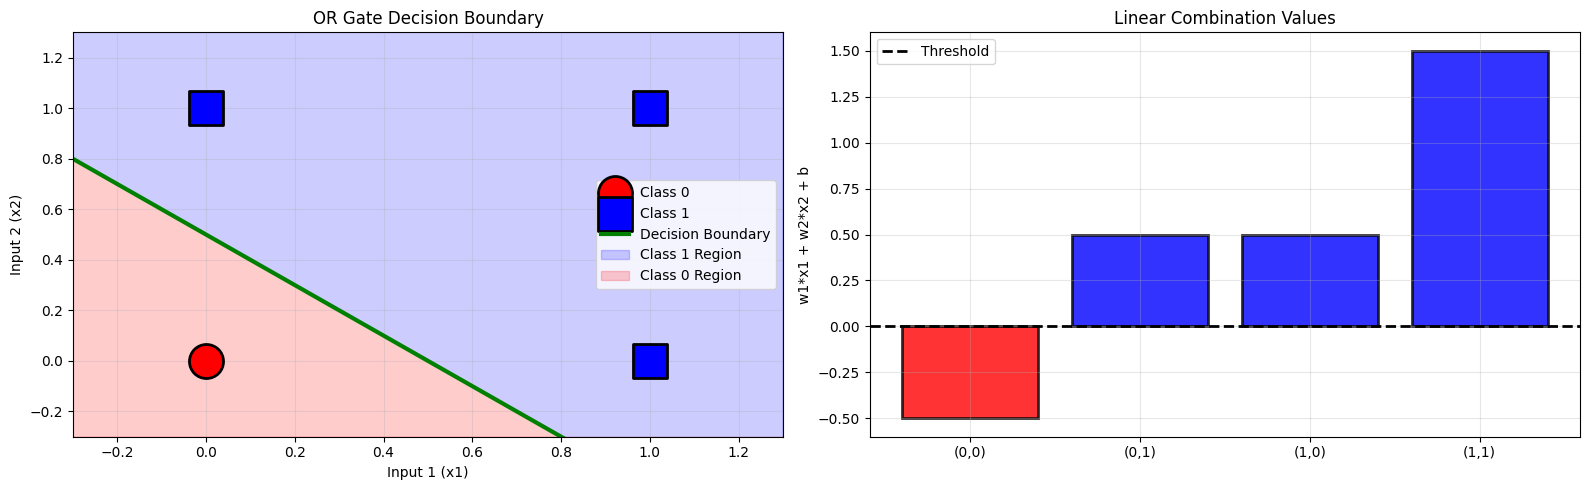


VERIFICATION RESULTS
Decision boundary: x2 = (-b - w1*x1) / w2 = (0.5 - 1.0 * x1) / 1.0
Linear values for each input:
Input (0, 0): 1.0*0 + 1.0*0 + -0.5 = -0.50 => Class 0 (<=0)
Input (0, 1): 1.0*0 + 1.0*1 + -0.5 = 0.50 => Class 1 (>0)
Input (1, 0): 1.0*1 + 1.0*0 + -0.5 = 0.50 => Class 1 (>0)
Input (1, 1): 1.0*1 + 1.0*1 + -0.5 = 1.50 => Class 1 (>0)

Point positions relative to boundary:
Point (0, 0): -0.500 => Below (Class 0)
Point (0, 1): 0.500 => Above (Class 1)
Point (1, 0): 0.500 => Above (Class 1)
Point (1, 1): 1.500 => Above (Class 1)


In [1]:
#OR gate hard coded weights

import numpy as np
import matplotlib.pyplot as plt

# Input samples for OR gate - directly as 1D arrays
X1 = np.array([0, 0, 1, 1])
X2 = np.array([0, 1, 0, 1])

# OR gate target outputs
y = np.array([[0], [1], [1], [1]])

print("OR GATE SINGLE PERCEPTRON HARD-CODED WEIGHTS")
print("-" * 60)

# Hardcoded weights and bias for OR gate perceptron
w1 = 1.0   # weight for X1
w2 = 1.0   # weight for X2
b = -0.5   # bias

print(f"Weights: w1 = {w1:.1f}, w2 = {w2:.1f}")
print(f"Bias: b = {b:.1f}")
print(f"Equation: {w1}*x1 + {w2}*x2 + {b} > 0 => output=1")

def step_function(x):
    return 1 if x > 0 else 0

# Perceptron prediction using formula directly
def perceptron_predict(X1, X2, w1, w2, b):
    linear = w1 * X1 + w2 * X2 + b
    predictions = np.array([step_function(z) for z in linear])
    return linear.reshape(-1, 1), predictions.reshape(-1, 1)

print("\nPREDICTIONS")
linear_values, predictions = perceptron_predict(X1, X2, w1, w2, b)

for i in range(len(X1)):
    x1_val, x2_val = X1[i], X2[i]
    linear_val = linear_values[i, 0]
    pred = int(predictions[i, 0])
    actual = int(y[i, 0])
    print(f"Input: ({x1_val}, {x2_val}) | Linear: {linear_val:5.1f} | Pred: {pred} | Actual: {actual}")

# Plotting decision boundary and points
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
# Class 0 points (red circles)
plt.scatter(X1[y.flatten() == 0], X2[y.flatten() == 0],
            s=600, c='red', marker='o', edgecolors='black', linewidth=2, label='Class 0', zorder=3)
# Class 1 points (blue squares)
plt.scatter(X1[y.flatten() == 1], X2[y.flatten() == 1],
            s=600, c='blue', marker='s', edgecolors='black', linewidth=2, label='Class 1', zorder=4)

# Decision boundary: w1*x1 + w2*x2 + b = 0 => x2 = (-b - w1*x1)/w2
x1_range = np.linspace(-0.3, 1.3, 100)
x2_boundary = (-b - w1 * x1_range) / w2

plt.plot(x1_range, x2_boundary, 'g', linewidth=3, label='Decision Boundary', zorder=2)
plt.fill_between(x1_range, x2_boundary, 1.3, alpha=0.2, color='blue', label='Class 1 Region')
plt.fill_between(x1_range, -0.3, x2_boundary, alpha=0.2, color='red', label='Class 0 Region')

plt.xlim(-0.3, 1.3)
plt.ylim(-0.3, 1.3)
plt.xlabel('Input 1 (x1)')
plt.ylabel('Input 2 (x2)')
plt.title('OR Gate Decision Boundary')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot linear combination bar chart
plt.subplot(1, 2, 2)
samples = ['(0,0)', '(0,1)', '(1,0)', '(1,1)']
linear_vals_flat = linear_values.flatten()
colors = ['red' if val <= 0 else 'blue' for val in linear_vals_flat]

plt.bar(samples, linear_vals_flat, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Threshold')
plt.ylabel('w1*x1 + w2*x2 + b')
plt.title('Linear Combination Values')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVERIFICATION RESULTS")
print(f"Decision boundary: x2 = (-b - w1*x1) / w2 = ({-b} - {w1} * x1) / {w2}")

print("Linear values for each input:")
for i in range(len(X1)):
    x1_val, x2_val = X1[i], X2[i]
    z = w1 * x1_val + w2 * x2_val + b
    class_str = 'Class 1 (>0)' if z > 0 else 'Class 0 (<=0)'
    print(f"Input ({x1_val}, {x2_val}): {w1}*{x1_val} + {w2}*{x2_val} + {b} = {z:.2f} => {class_str}")

print("\nPoint positions relative to boundary:")
for i in range(len(X1)):
    x1_val, x2_val = X1[i], X2[i]
    point_value = w1 * x1_val + w2 * x2_val + b
    side = "Above (Class 1)" if point_value > 0 else "Below (Class 0)"
    print(f"Point ({x1_val}, {x2_val}): {point_value:.3f} => {side}")
